In [1]:
import qsharp
import random
import json
import time
from diskcache import Cache
from matplotlib import pyplot as plt


cache = Cache("~/quant-arith-cache/")
qsharp.init(project_root="../")

@cache.memoize()
def estimate_resources_in_place_adder(op, n):
    est = qsharp.estimate(f"EstimateUtils.RunBinaryOpInPlace({n},{op})")
    return json.dumps(est)    

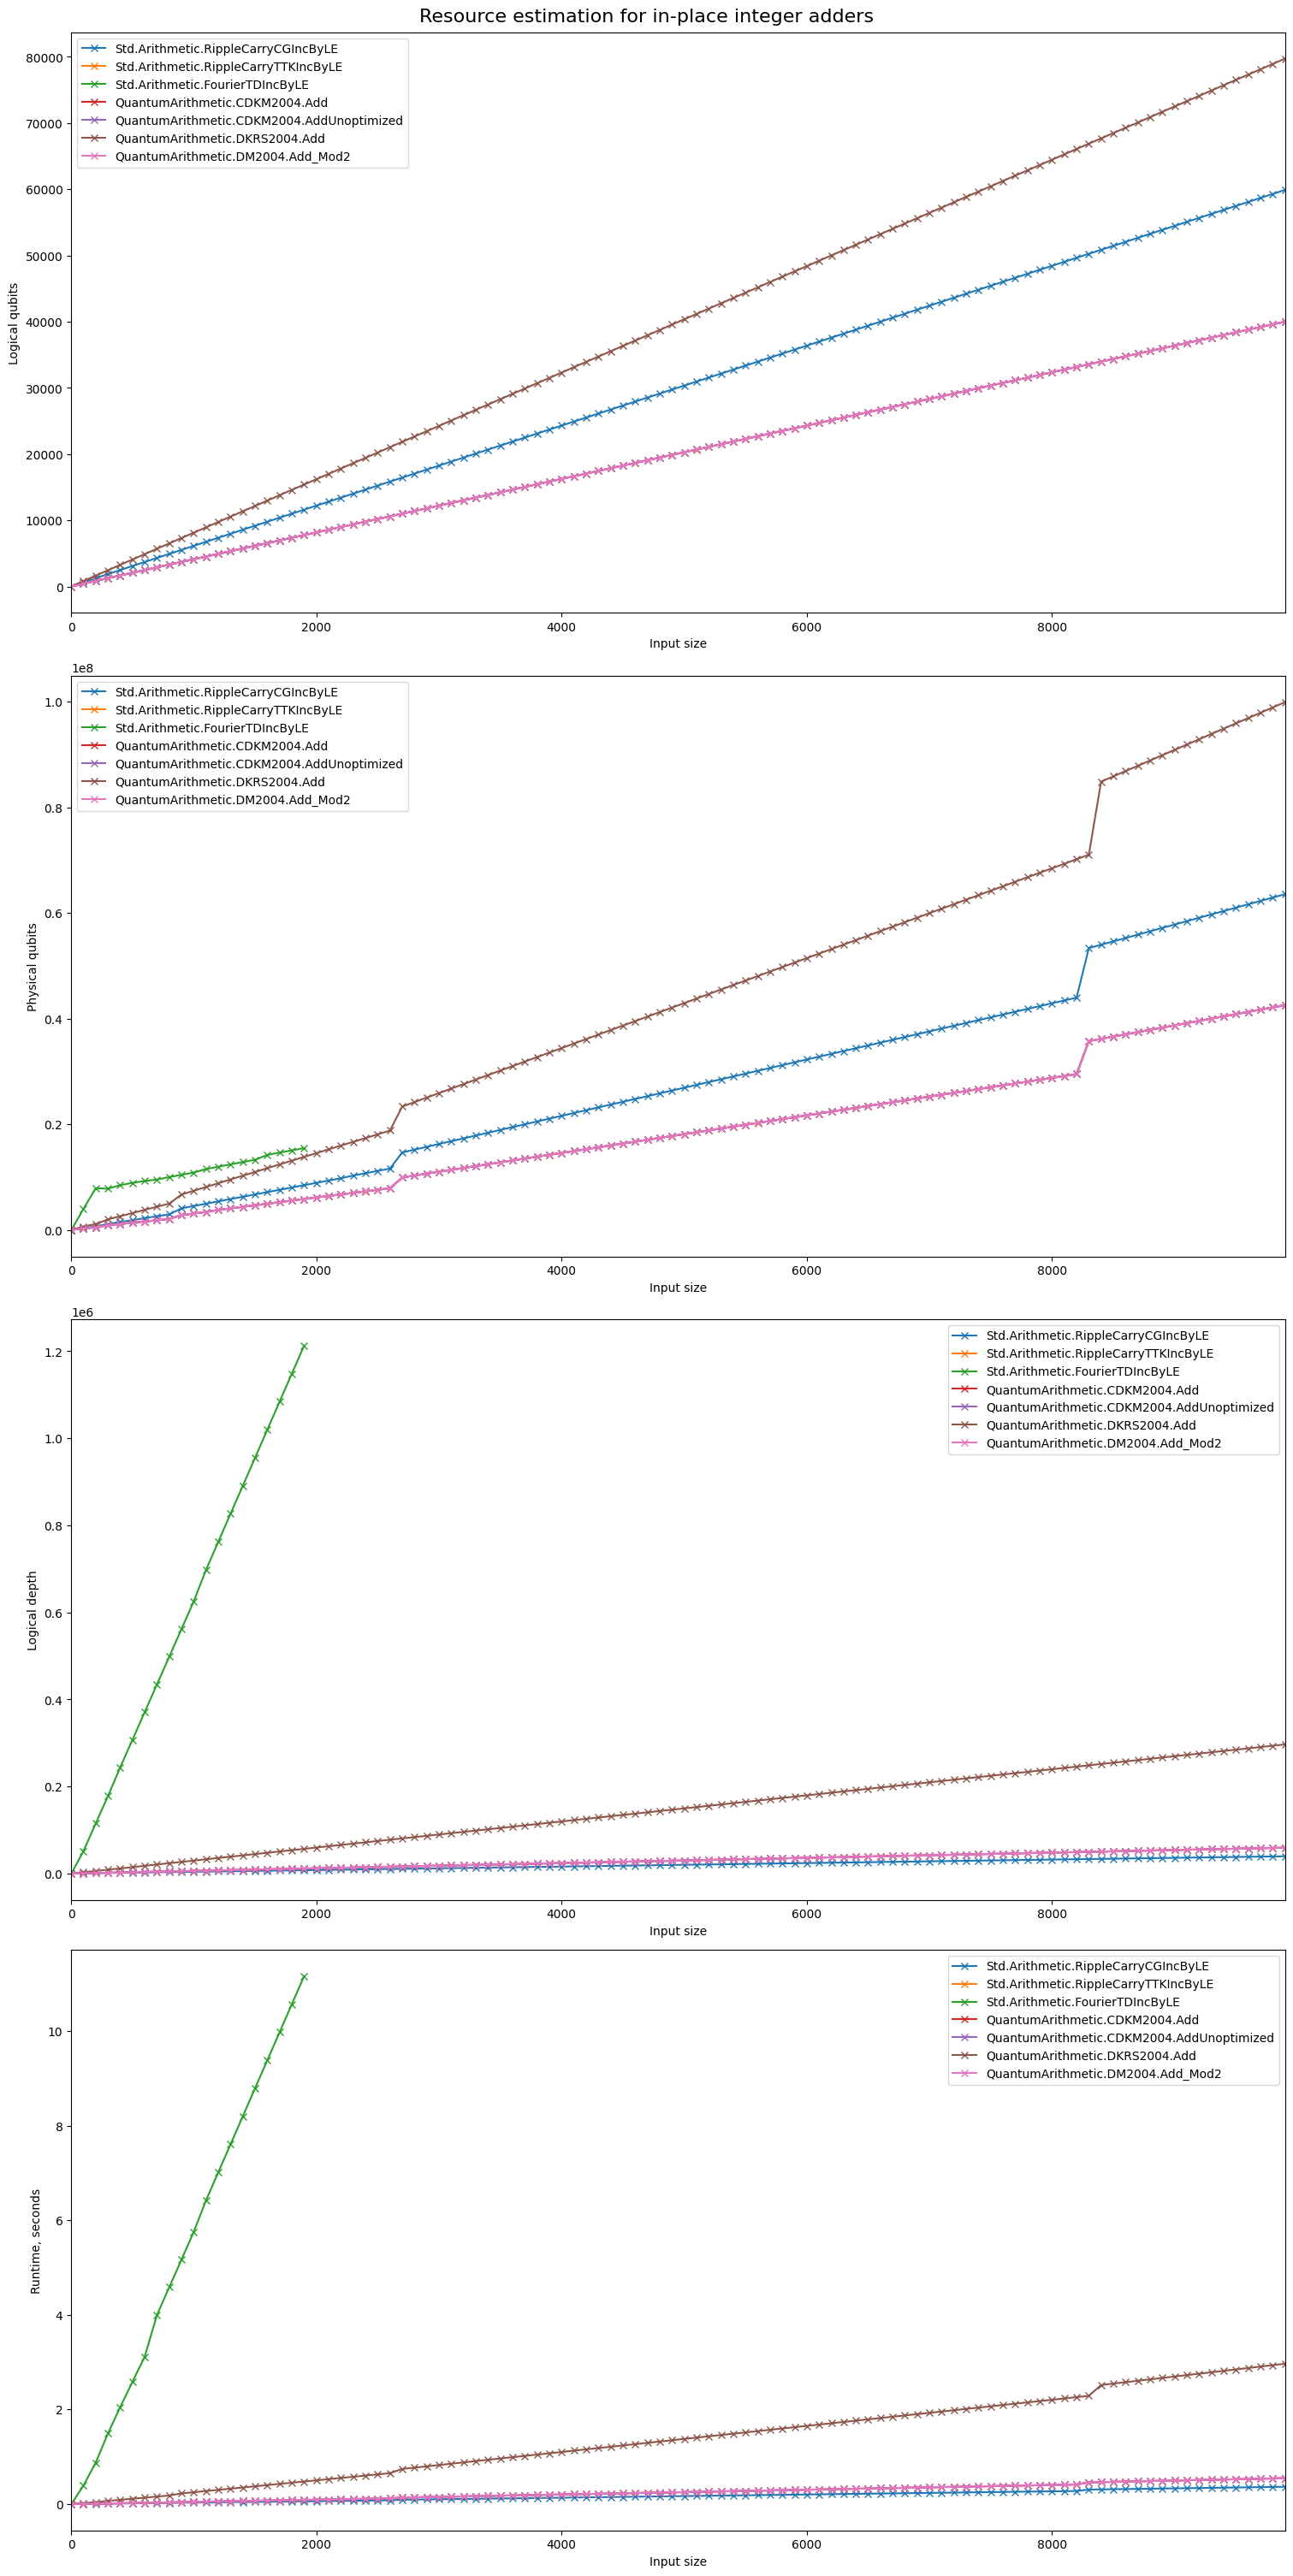

In [2]:
# These all are in-place adders modulo 2^n.
ops = [
  "Std.Arithmetic.RippleCarryCGIncByLE",
  "Std.Arithmetic.RippleCarryTTKIncByLE",
  "Std.Arithmetic.FourierTDIncByLE",
  "QuantumArithmetic.CDKM2004.Add",
  "QuantumArithmetic.CDKM2004.AddUnoptimized",
  "QuantumArithmetic.DKRS2004.Add",
  "QuantumArithmetic.DM2004.Add_Mod2",
]

n_range_default = [2]+list(range(100, 10000, 100))
n_ranges = {op: n_range_default for op in ops}
n_ranges["Std.Arithmetic.FourierTDIncByLE"] = [2]+list(range(100, 2000, 100))

metrics = ["Logical qubits", "Physical qubits", "Logical depth", "Runtime, seconds"]
charts = [{op: [] for op in ops} for _ in range(len(metrics))]

for op in ops:
    for n in n_ranges[op]:
        t0=time.time()
        estimates = json.loads(estimate_resources_in_place_adder(op, n))
        #print(n, op, time.time()-t0, flush=True)
        charts[0][op].append(estimates['physicalCounts']['breakdown']['algorithmicLogicalQubits'])
        charts[1][op].append(estimates['physicalCounts']['physicalQubits'])
        charts[2][op].append(estimates['physicalCounts']['breakdown']['logicalDepth'])
        charts[3][op].append(estimates['physicalCounts']['runtime']/10**9)

fig, ax = plt.subplots(figsize=(15, 30), nrows=len(metrics), ncols=1, constrained_layout=True)
for i in range(len(metrics)):
    for op in ops:
        ax[i].plot(n_ranges[op], charts[i][op], label=op, marker='x')
    ax[i].set_xlim([0,max(max(n_ranges[op]) for op in ops)])
    ax[i].legend()
    ax[i].set_xlabel('Input size')
    ax[i].set_ylabel(metrics[i])
fig.suptitle("Resource estimation for in-place integer adders", fontsize=16)
plt.show()